In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv('data/transformed_cleaned_vw_golf.csv')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
df.head()


Rows: 6,920 | Columns: 28


,index,brand,model,registration_date,year,price_in_euro,power_kw,power_ps,fuel_type,fuel_consumption_l_100km,...,mileage_per_year,color_black,color_blue,color_grey,color_other,color_red,color_silver,color_white,transmission_type_Automatic,transmission_type_Manual
0,213644,volkswagen,Volkswagen Golf,1995-08-01,1995,4970,66,90,Petrol,8.0,...,670.678574,False,True,False,False,False,False,False,False,True
1,213645,volkswagen,Volkswagen Golf,1995-02-01,1995,2590,66,90,Petrol,6.8,...,613.525300,False,True,False,False,False,False,False,True,False
2,213647,volkswagen,Volkswagen Golf,1995-11-01,1995,8900,128,174,Petrol,10.5,...,683.030774,False,True,False,False,False,False,False,True,False
3,213650,volkswagen,Volkswagen Golf,1995-11-01,1995,6399,44,60,Petrol,6.8,...,309.617701,False,True,False,False,False,False,False,False,True
4,213662,volkswagen,Volkswagen Golf,1995-06-01,1995,6600,66,90,Diesel,5.0,...,669.745364,False,False,False,False,True,False,False,False,True


In [3]:
feature_cols = [
    'T_model_age', 'T_car_age', 'T_power_kw', 'T_mileage', 'mileage_per_year',
    'fuel_consumption_l_100km',
    'transmission_type_Automatic', 'transmission_type_Manual',
    'color_black', 'color_blue', 'color_grey', 'color_other', 'color_red',
    'color_silver', 'color_white'
]

X = df[feature_cols].astype(float)
y = df['price_in_euro'].astype(float)

print('Feature matrix:', X.shape)
y.describe()


Feature matrix: (6920, 15)


count     6920.000000
mean     13595.728179
std       9254.426381
min        399.000000
25%       6750.000000
50%      12290.000000
75%      17990.000000
max      97050.000000
Name: price_in_euro, dtype: float64

In [4]:
corr = df[feature_cols + ['price_in_euro']].corr(numeric_only=True)
price_corr = corr['price_in_euro'].sort_values(ascending=False)
price_corr


price_in_euro                  1.000000
T_power_kw                     0.674538
transmission_type_Automatic    0.466808
color_red                      0.198084
color_white                    0.116456
color_other                    0.047075
color_grey                     0.031106
color_blue                    -0.060817
color_black                   -0.072843
color_silver                  -0.135825
fuel_consumption_l_100km      -0.208933
transmission_type_Manual      -0.466808
mileage_per_year              -0.609786
T_mileage                     -0.749034
T_car_age                     -0.841948
T_model_age                   -0.843118
Name: price_in_euro, dtype: float64

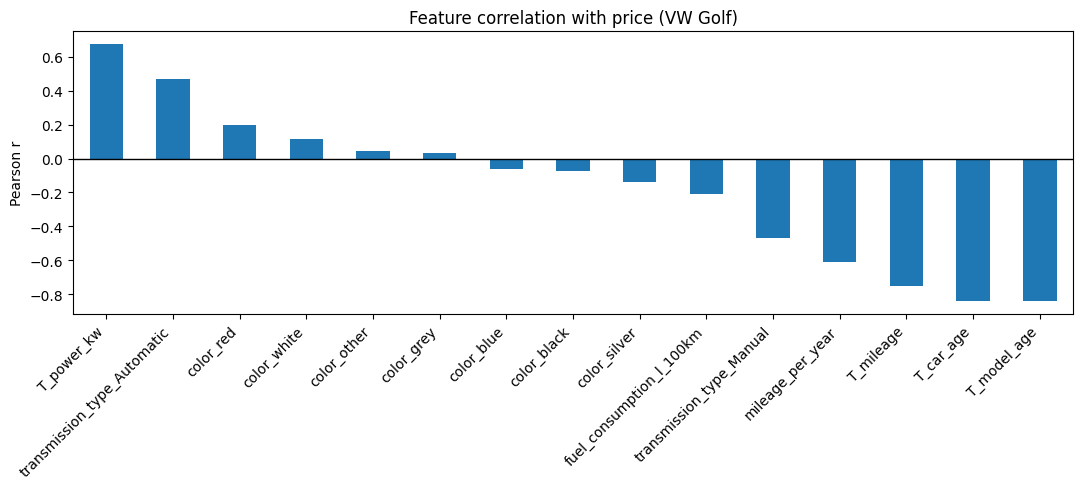

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
price_corr.drop('price_in_euro').plot(kind='bar', ax=ax)
ax.set_title('Feature correlation with price (VW Golf)')
ax.set_ylabel('Pearson r')
ax.axhline(0.0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [6]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)


def evaluate(y_true, y_pred, split_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{split_name}: RMSE={rmse:.2f}, R²={r2:.3f}")


train_pred = lr.predict(X_train)
val_pred = lr.predict(X_val)
test_pred = lr.predict(X_test)

evaluate(y_train, train_pred, 'Train')
evaluate(y_val, val_pred, 'Validation')
evaluate(y_test, test_pred, 'Test')


Train: RMSE=3469.05, R²=0.864
Validation: RMSE=4110.77, R²=0.804
Test: RMSE=3132.16, R²=0.872


In [7]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_,
    'abs_coefficient': np.abs(lr.coef_)
}).sort_values('abs_coefficient', ascending=False)
coef_df


,feature,coefficient,abs_coefficient
2,T_power_kw,8079.470580,8079.470580
1,T_car_age,-4770.463961,4770.463961
0,T_model_age,-1669.714010,1669.714010
7,transmission_type_Manual,-939.293186,939.293186
6,transmission_type_Automatic,939.293186,939.293186
11,color_other,499.330343,499.330343
5,fuel_consumption_l_100km,405.303406,405.303406
10,color_grey,-281.996913,281.996913
12,color_red,-245.748460,245.748460
13,color_silver,-202.690214,202.690214


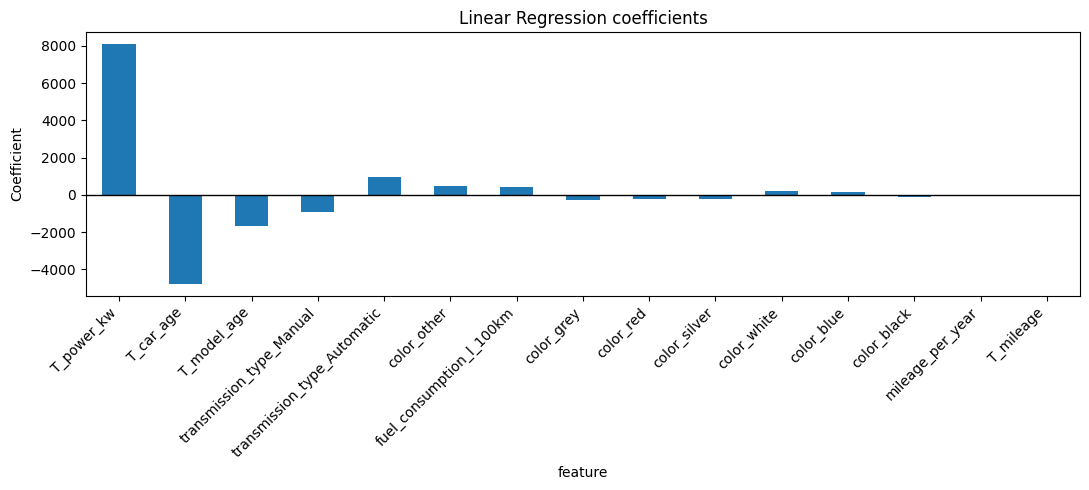

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
coef_df.set_index('feature')['coefficient'].plot(kind='bar', ax=ax)
ax.set_title('Linear Regression coefficients')
ax.set_ylabel('Coefficient')
ax.axhline(0.0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


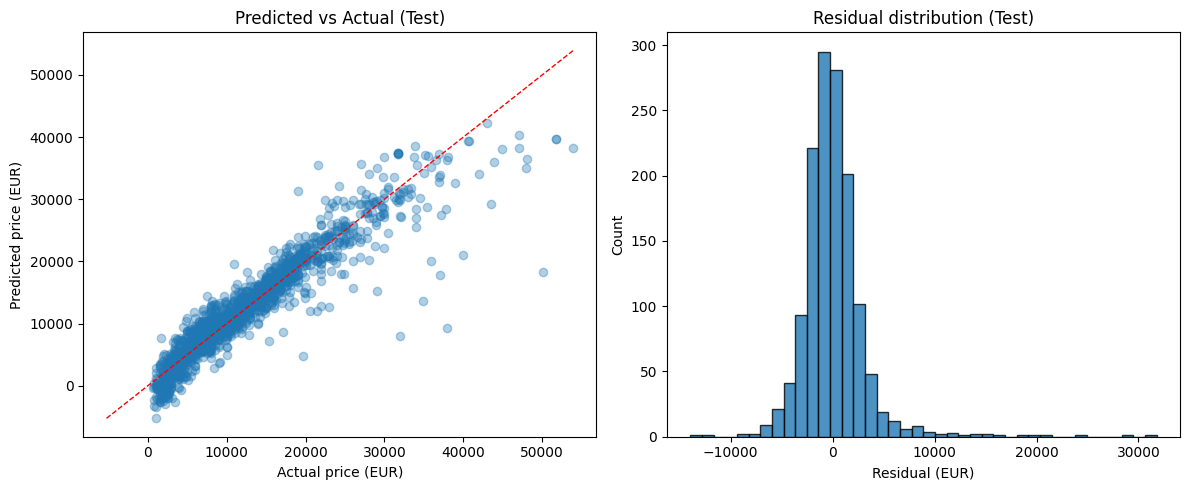

In [9]:
residuals = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, test_pred, alpha=0.35)
min_v = min(y_test.min(), test_pred.min())
max_v = max(y_test.max(), test_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1)
axes[0].set_title('Predicted vs Actual (Test)')
axes[0].set_xlabel('Actual price (EUR)')
axes[0].set_ylabel('Predicted price (EUR)')

axes[1].hist(residuals, bins=40, edgecolor='black', alpha=0.8)
axes[1].set_title('Residual distribution (Test)')
axes[1].set_xlabel('Residual (EUR)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
